In [4]:
import sys
print(sys.executable)

/opt/homebrew/opt/python@3.10/bin/python3.10


In [5]:
!pip --version

pip 25.3 from /Users/sakana/Library/Python/3.9/lib/python/site-packages/pip (python 3.9)


In [6]:
!{sys.executable} -m pip install scikit-learn

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 1.8 MB/s  0:00:05 eta 0:00:01
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [7]:
!{sys.executable} -m pip install --user scikit-learn

In [ ]:
import sys
import subprocess
import importlib

def install_and_import(package):
   
    try:
        
        importlib.import_module(package)
    except ImportError:
        
        print(f"Thư viện {package} chưa được cài. Đang cài đặt...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
    finally:
       
        globals()[package] = importlib.import_module(package)

required_packages = ['cv2', 'numpy', 'matplotlib', 'sklearn', 'scipy', 'skimage']
for pkg in required_packages:
    install_and_import(pkg)

import cv2 as cv               
import numpy as np         
import matplotlib.pyplot as quan  
from sklearn.cluster import KMeans   
from scipy import ndimage as ndi     
from skimage import filters, morphology, measure  


In [ ]:
try:
   
    img = cv.imread('hinh.jpg')
    if img is None:
        raise FileNotFoundError("Không tìm thấy file hinh.jpg")
    
    print(f"✓ Đọc ảnh thành công: kích thước {img.shape}")
    
    # Chuyển đổi không gian màu
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)   # BGR -> RGB (hiển thị đúng màu)
    img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY) # Ảnh xám
    
except Exception as e:
    print("❌ Lỗi đọc ảnh:", e)
    exit()

✓ Đọc ảnh thành công: kích thước (650, 1280, 3)


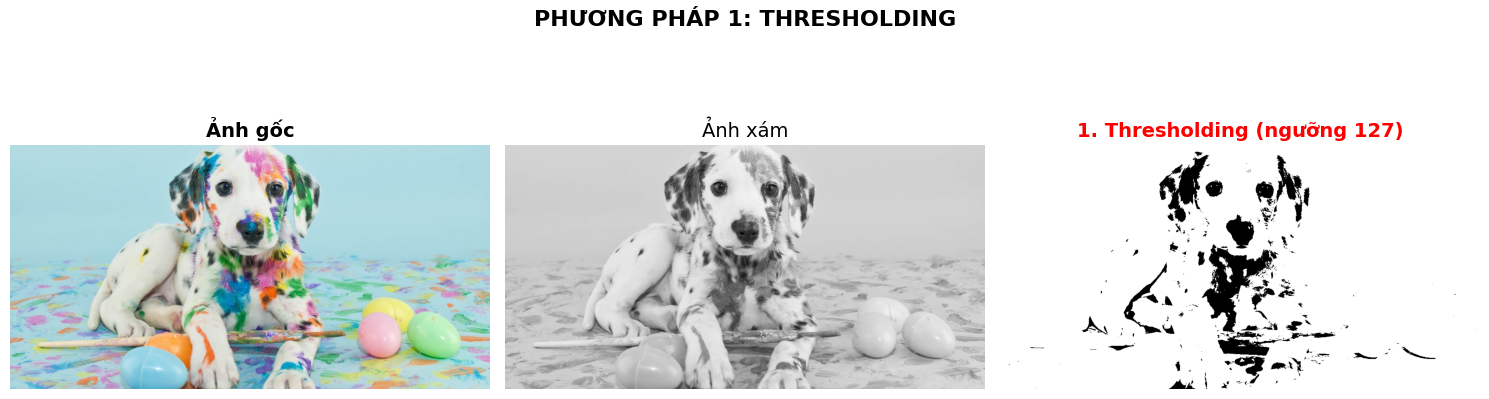

In [ ]:

# 1. THRESHOLDING 

_, thresh_binary = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

# Tạo figure riêng cho Thresholding
quan.figure(figsize=(15, 5))
quan.subplot(1, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(1, 3, 2)
quan.imshow(img_gray, cmap='gray')
quan.title('Ảnh xám', fontsize=14)
quan.axis('off')

quan.subplot(1, 3, 3)
quan.imshow(thresh_binary, cmap='gray')
quan.title('1. Thresholding (ngưỡng 127)', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 1: THRESHOLDING', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()

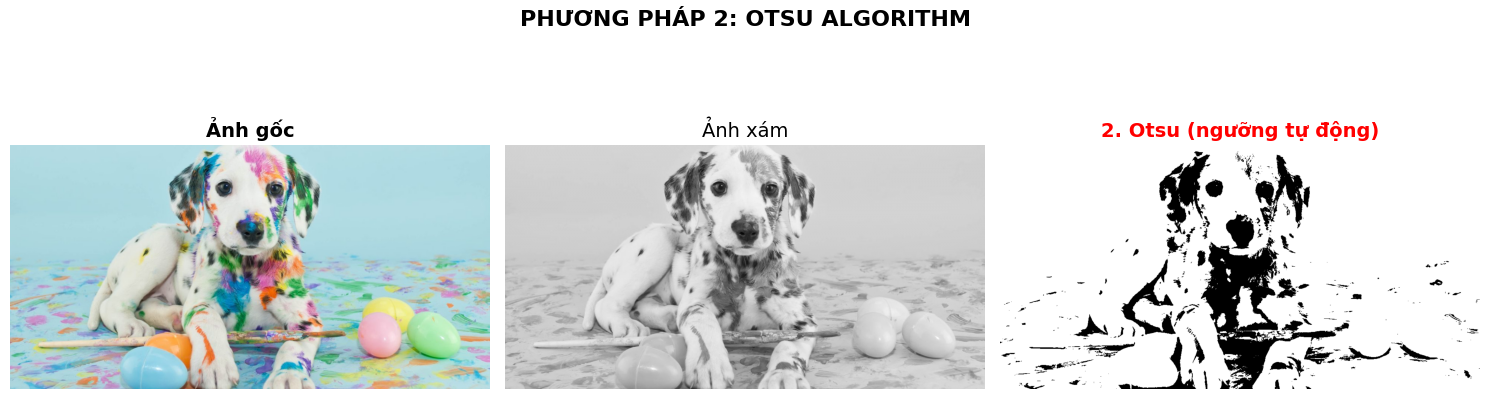

In [ ]:
# 2. OTSU ALGORITHM 
"""
NGUYÊN LÝ: Tự động tìm ngưỡng tối ưu dựa trên histogram
Đặc biệt hiệu quả với ảnh vân tay, ảnh có histogram hai đỉnh
"""
_, otsu = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Tạo figure riêng cho Otsu
quan.figure(figsize=(15, 5))
quan.subplot(1, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(1, 3, 2)
quan.imshow(img_gray, cmap='gray')
quan.title('Ảnh xám', fontsize=14)
quan.axis('off')

quan.subplot(1, 3, 3)
quan.imshow(otsu, cmap='gray')
quan.title('2. Otsu (ngưỡng tự động)', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 2: OTSU ALGORITHM', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()


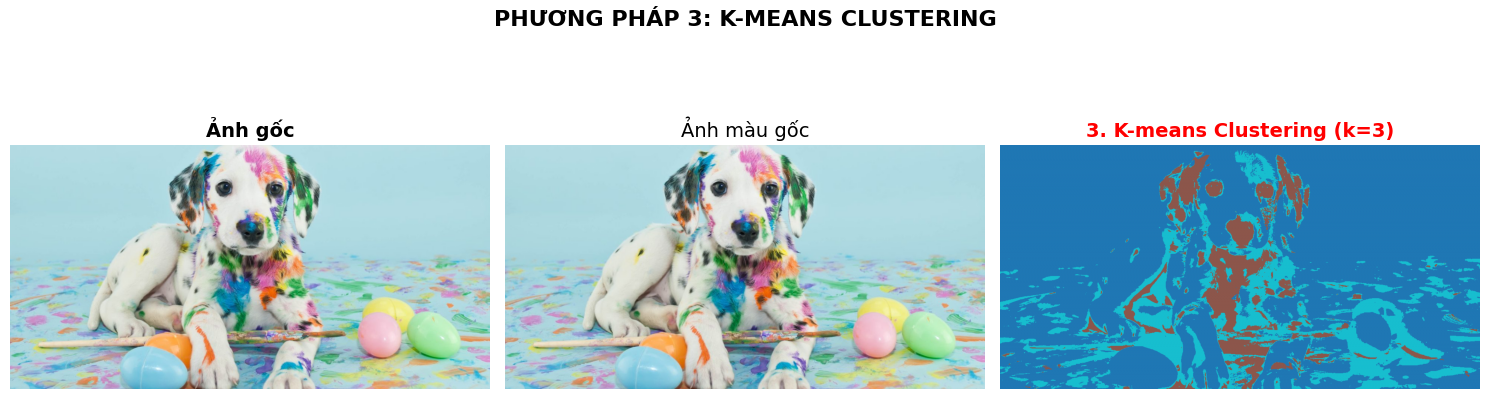

In [ ]:
# 3. K-MEANS CLUSTERING 

# Chuyển ảnh thành mảng 2D: mỗi hàng là 1 pixel (R,G,B)
pixels = img_rgb.reshape(-1, 3)
# Thực hiện K-means với 3 cụm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(pixels)
# Định hình lại thành ảnh
segmented_kmeans = labels.reshape(img_rgb.shape[:2])

# Tạo figure riêng cho K-means
quan.figure(figsize=(15, 5))
quan.subplot(1, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(1, 3, 2)
quan.imshow(img_rgb)
quan.title('Ảnh màu gốc', fontsize=14)
quan.axis('off')

quan.subplot(1, 3, 3)
quan.imshow(segmented_kmeans, cmap='tab10')
quan.title('3. K-means Clustering (k=3)', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 3: K-MEANS CLUSTERING', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()

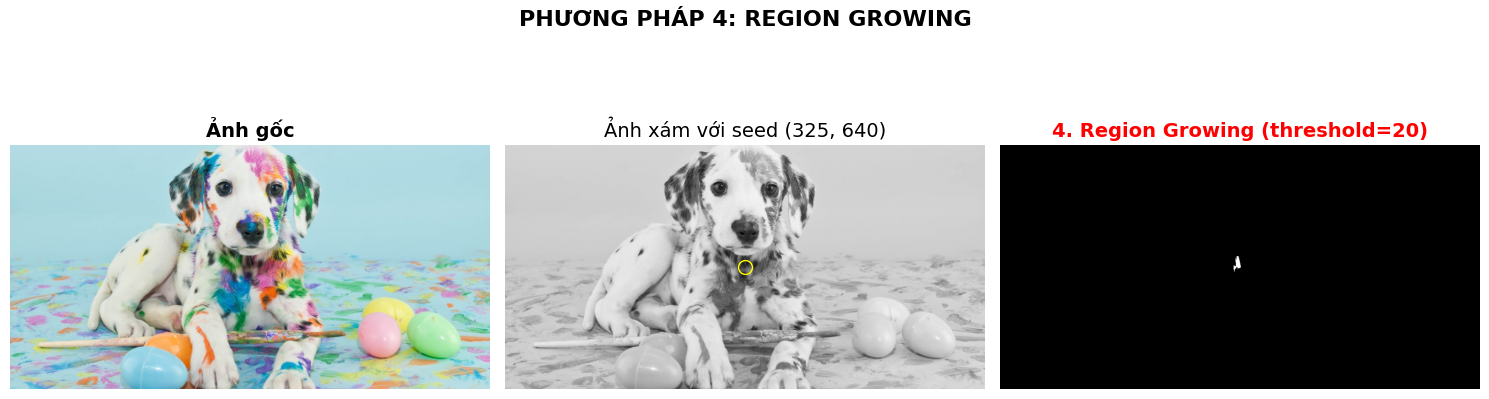

In [ ]:
# 4. REGION GROWING (Phát triển vùng) 

def region_growing(img, seed, threshold=10):
    h, w = img.shape
    visited = np.zeros_like(img, dtype=bool)
    region = np.zeros_like(img, dtype=np.uint8)
    stack = [seed]
    seed_val = img[seed]
    
    while stack:
        x, y = stack.pop()
        if visited[x, y]:
            continue
        visited[x, y] = True
        
        if abs(int(img[x, y]) - int(seed_val)) <= threshold:
            region[x, y] = 255
            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                nx, ny = x+dx, y+dy
                if 0 <= nx < h and 0 <= ny < w and not visited[nx, ny]:
                    stack.append((nx, ny))
    return region

# Chọn seed là tâm ảnh
h, w = img_gray.shape
seed_point = (h//2, w//2)
region_grown = region_growing(img_gray, seed_point, threshold=20)

# Tạo figure riêng cho Region Growing
quan.figure(figsize=(15, 5))
quan.subplot(1, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(1, 3, 2)
quan.imshow(img_gray, cmap='gray')
quan.plot(seed_point[1], seed_point[0], 'ro', markersize=10, markeredgecolor='yellow', markerfacecolor='none', linewidth=2)
quan.title(f'Ảnh xám với seed {seed_point}', fontsize=14)
quan.axis('off')

quan.subplot(1, 3, 3)
quan.imshow(region_grown, cmap='gray')
quan.title(f'4. Region Growing (threshold=20)', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 4: REGION GROWING', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()

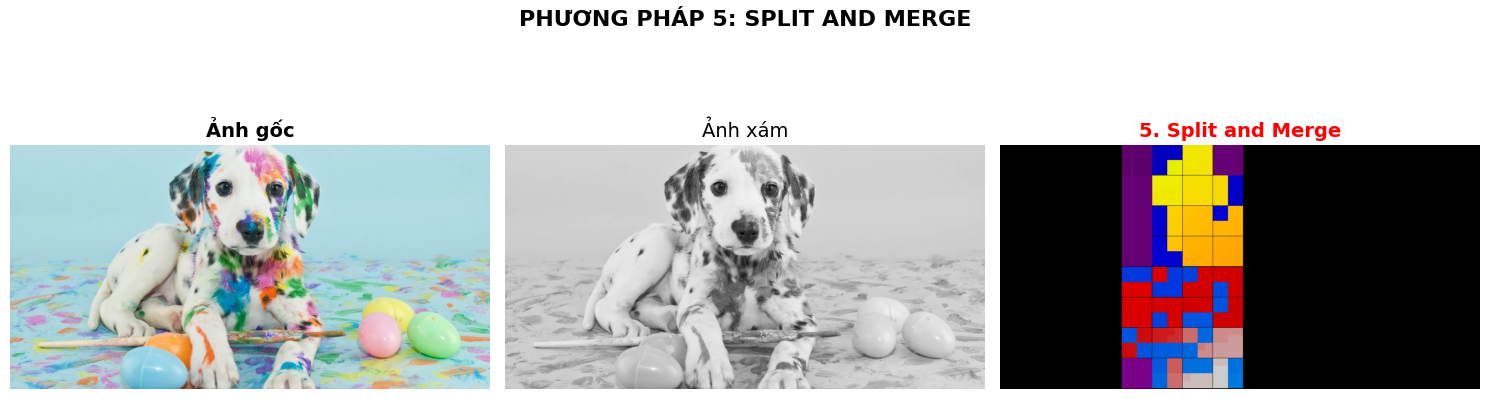

In [ ]:
# 5. SPLIT AND MERGE (Chia và hợp nhất) 
def split_and_merge(img, min_size=32, threshold=25):
    h, w = img.shape
    size = min(h, w)
    img_square = img[:size, :size]
    regions = np.zeros((size, size), dtype=np.int32)
    
    def split(roi_x, roi_y, sz, label):
        x1, y1 = roi_x, roi_y
        x2, y2 = roi_x + sz, roi_y + sz
        sub_img = img_square[y1:y2, x1:x2]
        std = np.std(sub_img)
        
        if sz <= min_size or std < threshold:
            regions[y1:y2, x1:x2] = label
        else:
            half = sz // 2
            split(x1, y1, half, label*4 + 1)
            split(x1 + half, y1, half, label*4 + 2)
            split(x1, y1 + half, half, label*4 + 3)
            split(x1 + half, y1 + half, half, label*4 + 4)
    
    split(0, 0, size, 1)
    full_result = np.zeros((h, w), dtype=np.int32)
    full_result[:size, :size] = regions
    return full_result

split_merge_result = split_and_merge(img_gray, min_size=32, threshold=25)

# Tạo figure riêng cho Split and Merge
quan.figure(figsize=(15, 5))
quan.subplot(1, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(1, 3, 2)
quan.imshow(img_gray, cmap='gray')
quan.title('Ảnh xám', fontsize=14)
quan.axis('off')

quan.subplot(1, 3, 3)
quan.imshow(split_merge_result, cmap='nipy_spectral')
quan.title('5. Split and Merge', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 5: SPLIT AND MERGE', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()



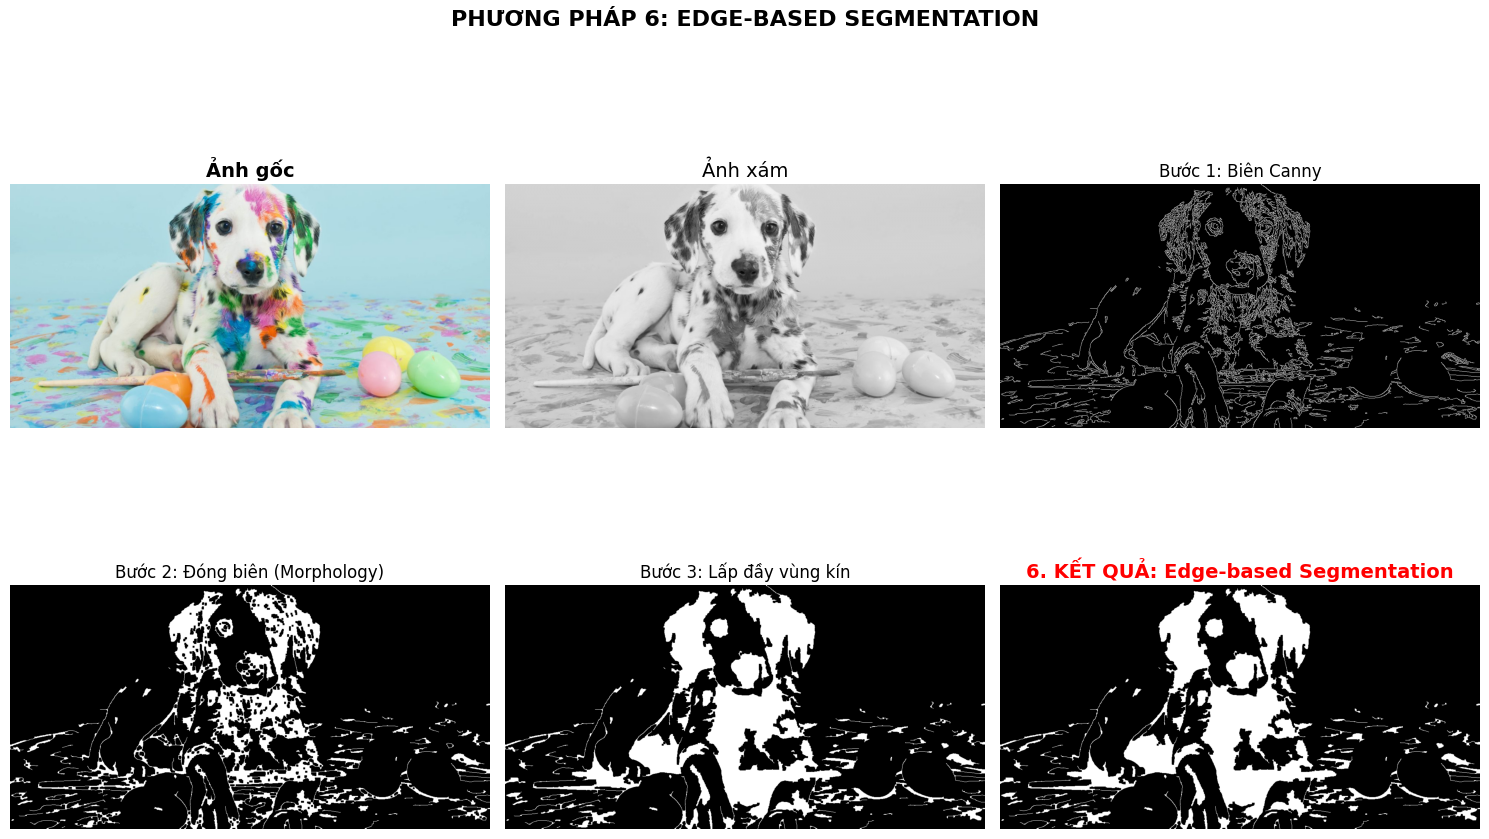

In [ ]:
# 6. EDGE-BASED SEGMENTATION 

# Phát hiện biên Canny
edges = cv.Canny(img_gray, 50, 150)

# Đóng các khoảng hở trên biên
kernel = np.ones((3,3), np.uint8)
closed_edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=2)

# Lấp đầy vùng kín
filled = ndi.binary_fill_holes(closed_edges).astype(np.uint8) * 255

# Tạo figure riêng cho Edge-based Segmentation
quan.figure(figsize=(15, 10))

# Hàng 1: Ảnh gốc và ảnh xám
quan.subplot(2, 3, 1)
quan.imshow(img_rgb)
quan.title('Ảnh gốc', fontsize=14, fontweight='bold')
quan.axis('off')

quan.subplot(2, 3, 2)
quan.imshow(img_gray, cmap='gray')
quan.title('Ảnh xám', fontsize=14)
quan.axis('off')

# Hàng 2: Các bước xử lý
quan.subplot(2, 3, 3)
quan.imshow(edges, cmap='gray')
quan.title('Bước 1: Biên Canny', fontsize=12)
quan.axis('off')

quan.subplot(2, 3, 4)
quan.imshow(closed_edges, cmap='gray')
quan.title('Bước 2: Đóng biên (Morphology)', fontsize=12)
quan.axis('off')

quan.subplot(2, 3, 5)
quan.imshow(filled, cmap='gray')
quan.title('Bước 3: Lấp đầy vùng kín', fontsize=12)
quan.axis('off')

quan.subplot(2, 3, 6)
quan.imshow(filled, cmap='gray')
quan.title('6. KẾT QUẢ: Edge-based Segmentation', fontsize=14, color='red', fontweight='bold')
quan.axis('off')

quan.suptitle('PHƯƠNG PHÁP 6: EDGE-BASED SEGMENTATION', fontsize=16, fontweight='bold')
quan.tight_layout()
quan.show()
